Анализ результатов эксперимента. Группа 1 - контрольная группа. Группа 2 - тестовая группа.
Эксперимент проходил с 2025-11-21 по 2025-11-27 включительно.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandahouse
from datetime import date
import io
from read_db.CH import Getch
import sys
import os
from scipy import stats

In [23]:
connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator'
}

q = """
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20251220.feed_actions 
WHERE toDate(time) between '2025-11-21' and '2025-11-27'
    and exp_group in (1,2)
GROUP BY exp_group, user_id
"""

df = pandahouse.read_clickhouse(q, connection=connection)

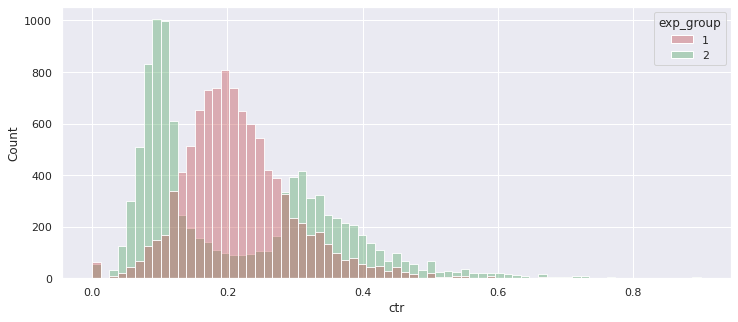

In [24]:
sns.set(rc={'figure.figsize':(12,5)})

groups = sns.histplot(data = df, 
              x='ctr', 
              hue='exp_group', 
              palette = ['r', 'g'],
              alpha=0.4,
              kde=False)

Средние значения (слева сглаженные значения):
0.21527988017565183 0.216773994120072
0.21250810594606076 0.2161016893237817
Дисперсии:
0.004888493823087572 0.0068837939124764096
0.015218292895291823 0.02041185609414384


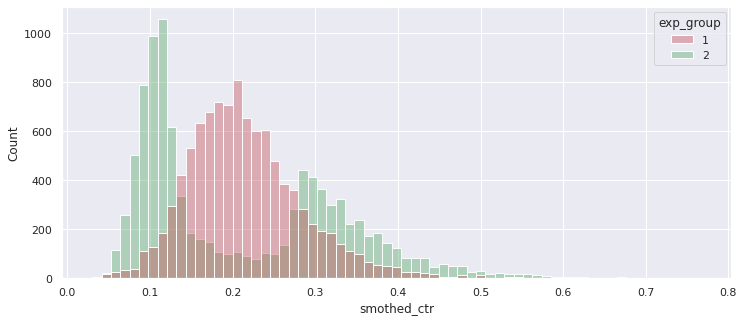

In [28]:
# Сглаженный CTR

def get_smothed_ctr(user_likes, user_views, global_ctr, alpha):
    smothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
    return smothed_ctr

global_ctr_1 = df[df.exp_group == 1].likes.sum()/df[df.exp_group == 1].views.sum()
global_ctr_2 = df[df.exp_group == 2].likes.sum()/df[df.exp_group == 2].views.sum()

group1 = df[df.exp_group == 1].copy()
group2 = df[df.exp_group == 2].copy()

group1['smothed_ctr'] = df.apply(lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_1, 5), axis=1)
group2['smothed_ctr'] = df.apply(lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_2, 5), axis=1)

df_smothed = pd.concat([group1, group2], ignore_index=True)

sns.histplot(data = df_smothed, 
              x='smothed_ctr', 
              hue='exp_group', 
              palette = ['r', 'g'],
              alpha=0.4,
              kde=False)

print('Средние значения (слева сглаженные значения):')
print(group1['smothed_ctr'].mean(), df[df.exp_group == 1]['ctr'].mean())
print(group2['smothed_ctr'].mean(), df[df.exp_group == 2]['ctr'].mean())
print('Дисперсии:')
print(group1['smothed_ctr'].var(), df[df.exp_group == 1]['ctr'].var())
print(group2['smothed_ctr'].var(), df[df.exp_group == 2]['ctr'].var())

Визуально различия в двух группах явно есть. Докажем это еще и формально, используя различные тесты с последующим сравнением их применимости. 

In [15]:
### Т-тест

statistic, p_value = stats.ttest_ind(df[df.exp_group == 1].ctr,
                df[df.exp_group == 2].ctr,
                equal_var=False)
print(f'Величина статистики: {round(statistic, 10)}\nВеличина p-значения: {round(p_value, 10)}')

Величина статистики: 0.4051491913
Величина p-значения: 0.6853733311


In [16]:
### T-тест на сглаженном CTR

statistic, p_value = stats.ttest_ind(df_smothed[df_smothed.exp_group == 1].smothed_ctr,
                df_smothed[df_smothed.exp_group == 2].smothed_ctr,
                equal_var=False)
print(f'Величина статистики: {round(statistic, 10)}\nВеличина p-значения: {round(p_value, 10)}')

Величина статистики: 1.9460491517
Величина p-значения: 0.0516667902


Интерпретируя t-тесты, можно сказать следующее:
    1. Тест на исходных значениях CTR не показал статистически значимых различий в двух выборках, что выглядит сомнительно, если брать во внимание, что визуально различия очевидны. Результаты теста подверждают необходимость соблюдения необходимых условий для использования t-теста: в нашем случае - это, как минимум, отсутствие высокой вероятности больших по модулю отклонений.
    2. В свою очередь на сглаженном CTR тест показал достаточно сильное различие в исследуемых метриках двух выборок, однако p-значение хоть и близко к удовлетворительной для нас величине, но мы всё равно не можем принять альтернативную гипотезу.
    3. Принимая во внимание всё вышенаписанное, можно сказать, что для сбора более оснвовательных доказательств необходимо проведение других тестов.

In [18]:
### Тест Манна-Уитни

statistic, p_value = stats.mannwhitneyu(df[df.exp_group == 1].ctr, 
                   df[df.exp_group == 2].ctr,
                   alternative = 'two-sided')

print(f'Величина статистики: {round(statistic, 10)}\nВеличина p-значения: {round(p_value, 10)}')

Величина статистики: 55189913.0
Величина p-значения: 0.0


Интерпретация: тест Манна-Уитни показал сильные различия в двух группах, p-значение < 0.001, что говорит о низкой вероятности получения таких результатов случайно. Стоит помнить, что для теста Манна-Уитни даже маленькие различия в очень больших выборках (как у нас) дадут очень низкое p-значения, однако, опять же, визуальный анализ подсказывает, что отличия значительные и эффект от проведения теста имеется (положителньый или отрицательный - это уже другой вопрос). На всякий случай проведем ещё и Пуассоновский бутстреп и Тест Манна-Уитни поверх бакетного преобразования, который в нашем случае может быть точнее и чувствительнее обычного теста Манна-Уитни.

<Axes: ylabel='Count'>

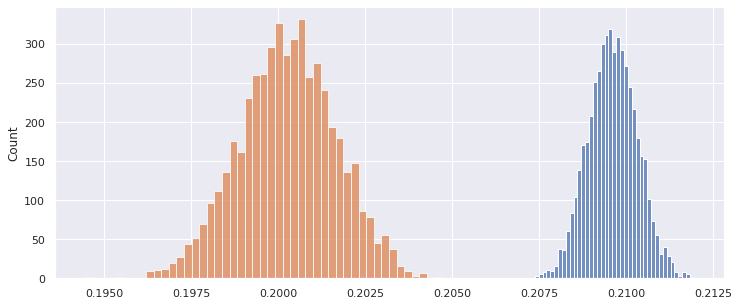

In [30]:
### Пуассоновский бутстреп

def bootstrap(likes1, views1, likes2, views2, n_bootstrap=5000):

    poisson_bootstraps1 = stats.poisson(1).rvs(
        (n_bootstrap, len(likes1))).astype(np.int64)

    poisson_bootstraps2 = stats.poisson(1).rvs(
            (n_bootstrap, len(likes2))).astype(np.int64)
    
    globalCTR1 = (poisson_bootstraps1*likes1).sum(axis=1)/(poisson_bootstraps1*views1).sum(axis=1)
    
    globalCTR2 = (poisson_bootstraps2*likes2).sum(axis=1)/(poisson_bootstraps2*views2).sum(axis=1)

    return globalCTR1, globalCTR2

likes1 = df[df.exp_group == 1].likes.to_numpy()
views1 = df[df.exp_group == 1].views.to_numpy()
likes2 = df[df.exp_group == 2].likes.to_numpy()
views2 = df[df.exp_group == 2].views.to_numpy()

ctr1, ctr2 = bootstrap(likes1, views1, likes2, views2)

sns.histplot(ctr1)
sns.histplot(ctr2)

<Axes: ylabel='Count'>

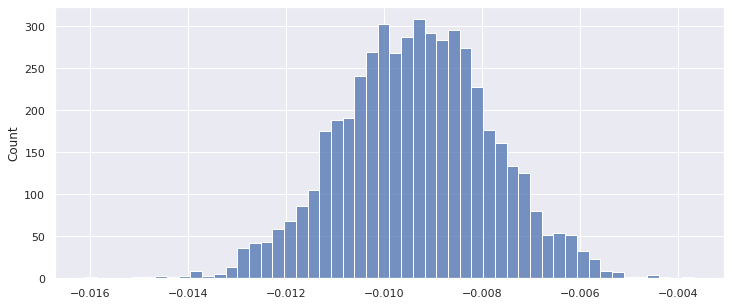

In [31]:
#Разница между глобальными CTR
sns.histplot(ctr2 - ctr1)

Интерпретация: явно видим различия в глобальных бутстреп-CTR двух групп, причем на гистограмме распределения разницы видим, что тестовая группа проигрывает контрольной по величине CTR.

In [21]:
### Тест Манна-Уитни поверх бакетного преобразования

q = """

SELECT exp_group, bucket,
    sum(likes)/sum(views) as bucket_ctr,
    quantileExact(0.9)(ctr) as ctr9
FROM (SELECT exp_group, 
        xxHash64(user_id)%50 as bucket,
        user_id,
        sum(action = 'like') as likes,
        sum(action = 'view') as views,
        likes/views as ctr
    FROM simulator_20251220.feed_actions 
    WHERE toDate(time) between '2025-11-21' and '2025-11-27'
        and exp_group in (1,2)
    GROUP BY exp_group, bucket, user_id)
GROUP BY exp_group, bucket
"""

df = pandahouse.read_clickhouse(q, connection=connection)

stats.mannwhitneyu(df[df.exp_group == 1].bucket_ctr, 
                   df[df.exp_group == 2].bucket_ctr, 
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=1997.0, pvalue=2.6576427804010095e-07)

Интерпретация: более точный для CTR по сравнению с обычным тестом тест Манна-Уитни поверх бакетного преобразования так же показывает различия, хоть уже и не такие сильные, в двух группах. P-значения так же находится на низком уровне.

Общий вывод.
На графиках распределения мы видим следующую картину: новая рекомендательная система дала заметный положительный эффект на каких-то пользователях, что привело к увеличению CTR, однако ещё заметнее обратная ситуация, где CTR уменьшился, и таких наблюдей значительно больше, чем "хороших". Возможно, такое могло произойти из-за узконаправленности новых рекомендаций, то есть, к примеру, эти рекомендации хорошо работают на аудиторию 50+ лет, а на людей 25 лет и ниже сильно хуже, в виду каких-то возрастных специфик. Или, если предположить, что новый алгоритм рекомендаций основывается на поведении пользователя в прошлом, алгоритм работает плохо и чаще ошибается в своих предсказаниях, чем делает правильные выводы.

Рекомендации.
Необходима доработка алгоритма, потому что, хотя мы и наблюдаем некое улучшение показателя, а средние значения вообще почти не изменились, но частота встречи низкой величины CTR значительно увеличилась, что говорит о необходимости проведении детального сегментированного анализа (по возрасту, месту жительства и т.д.) для выявления ошибок и слабых мест алгоритма.